![Banner](../../imgaes/banner_ch01.png)


# 1.1 Fundamentals of Point Patterns

**Part:** 1:  Point Pattern Analysis (Chapter 1.1 of 5)

**Dataset:** Buffalo crime incidents, 2018 (`data/crime_data_2018.csv`, `data/buffalo_city.shp`)

**Focus:** Point pattern data structures, observation windows, marks, and complete spatial randomness (CSR)

**Library:** `spatialstats.pointpattern` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [What is a Point Pattern?](#2.-What-is-a-Point-Pattern?)

3. [Point Processes and Complete Spatial Randomness](#3.-Point-Processes-and-Complete-Spatial-Randomness)

4. [Python Setup](#4.-Python-Setup)

5. [Load and Explore the Buffalo Crime Data](#5.-Load-and-Explore-the-Buffalo-Crime-Data)

   - 5.1 [A coordinate reference system problem](#5.1-A-coordinate-reference-system-problem)

6. [Building the Observation Window](#6.-Building-the-Observation-Window)

7. [Constructing the Point Pattern](#7.-Constructing-the-Point-Pattern)

8. [Marks: Crime Type as a Categorical Mark](#8.-Marks:-Crime-Type-as-a-Categorical-Mark)

9. [Duplicate Locations](#9.-Duplicate-Locations)

10. [Alternative Windows: Bounding Box, Convex Hull, City Boundary](#10.-Alternative-Windows:-Bounding-Box,-Convex-Hull,-City-Boundary)

11. [A First Look at Randomness](#11.-A-First-Look-at-Randomness)

12. [Summary and Conclusions](#12.-Summary-and-Conclusions)

13. [Resources](#13.-Resources)

***
## 1. Overview

Point pattern analysis is the statistical study of **where events happen**. Unlike the lattice data of
Part 2 (one fixed value per county) or the geostatistical fields of Part 7 (a continuous quantity sampled at
chosen locations), here the **locations themselves are the random outcome**. A crime location, a disease case,
a tree in a forest plot — the question is not "what is the value here?" but "why are the events *here* and not
somewhere else?"

This chapter builds the vocabulary and data structures that every later chapter in Part 1 relies on, using
**14,001 crime incidents recorded in Buffalo, NY in 2018** as the running example.

| Step | What we do |
|------|------------|
| Concepts | Define events, marks, the observation window, and first- vs second-order structure |
| Theory | State complete spatial randomness (CSR) as the homogeneous Poisson process, and preview its clustered/regular alternatives |
| Data | Load the crime incidents and the city boundary; **diagnose and fix a coordinate reference system (CRS) error** in the source files |
| `Window` | Build the observation window from the city boundary |
| `PointPattern` | Attach the events to that window, with crime type as a mark |
| Duplicates | Detect and handle events that share a geocoded location |
| Comparison | Contrast the city-boundary window with a bounding box and a convex hull |
| CSR preview | Simulate a CSR pattern with the same count and window, and look at it next to the real data |

By the end you will have a validated `PointPattern` object — reprojected, windowed, marked, and
deduplicated — that the rest of Part 1 (intensity, second-order functions, hypothesis tests) builds on directly.

***
## 2. What is a Point Pattern?

### 2.1 Events, not measurements

A **point pattern** is a set of locations $\{\mathbf{s}_1, \dots, \mathbf{s}_n\}$ in a region $D \subset \mathbb{R}^2$,
where the locations themselves were generated by some underlying process. Following convention, we call each
location an **event**, to distinguish it from an arbitrary point of $D$.

This is a different kind of randomness from the other two data types met in Part 0:

| Data type | What is random | Example | Part |
|---|---|---|---|
| Geostatistical field | A value $Z(\mathbf{s})$, sampled at chosen locations | PM2.5 at monitoring stations | 7 |
| Lattice (areal) | A value $Z_i$ for each of a fixed set of regions | Diabetes prevalence by county | 2–6 |
| **Point pattern** | **The locations $\{\mathbf{s}_i\}$ themselves** | Crime incidents, disease cases, trees | **1** |

### 2.2 The observation window

A point pattern is only meaningful together with the region $W \subset \mathbb{R}^2$ in which events were
*capable of being observed* — the **observation window**. $W$ is not optional bookkeeping: it is the denominator
of every intensity estimate ($n / |W|$) and the domain over which every summary function integrates. Choosing it
badly quietly changes every number that follows (Section 10 shows this directly).

### 2.3 Marks

An event can carry an attached attribute, called a **mark**: categorical (crime type, tree species) or
numeric (magnitude, diameter at breast height). A pattern with marks is a **marked point process**; the
marks add a further layer of structure — are events of type A found near events of type B? (Part 1.4).

### 2.4 First-order and second-order structure

Two questions organise the whole of Part 1:

- **First-order (intensity):** how does the *average density* of events vary over $D$? This is a question about
  $\lambda(\mathbf{s})$, the expected number of events per unit area at $\mathbf{s}$ (Chapter 1.2).
- **Second-order (interaction):** *given* the intensity, do events attract or repel each other at some spatial
  scale — beyond what the intensity alone predicts? This is a question about pairs of events (Chapter 1.3).

A pattern can have wildly non-constant intensity (more crime downtown) while still being "CSR-like" in its
second-order structure once that intensity trend is accounted for (Chapter 1.4's inhomogeneous K function) — the
two questions are logically separate, even though a raw map conflates them.

***
## 3. Point Processes and Complete Spatial Randomness

### 3.1 The formal model

A (spatial) **point process** is a random mechanism that produces a countable set of events in $D$. It is
characterised by its **counting measure** $N(B)$ = the (random) number of events falling in a sub-region
$B \subseteq D$, and by its **intensity function**

$$
\lambda(\mathbf{s}) \;=\; \lim_{|d\mathbf{s}| \to 0} \frac{\mathbb{E}\,N(d\mathbf{s})}{|d\mathbf{s}|}.
$$

### 3.2 Complete spatial randomness (CSR)

The reference model against which every other pattern is judged is the **homogeneous Poisson process**:

$$
N(B) \sim \text{Poisson}\big(\lambda\,|B|\big) \quad \text{for every } B \subseteq W,
$$

with $\lambda(\mathbf{s}) = \lambda$ constant, and counts in disjoint regions **independent** of each other. This
is **complete spatial randomness (CSR)**: no attraction, no repulsion, no drift in density. It plays the same role
in point pattern analysis that the null of "no spatial autocorrelation" plays in Part 2.

Two variants appear in this package, matching two ways of conditioning on what is observed:

| Variant | Count $n$ | Construction | `spatialstats` |
|---|---|---|---|
| **Poisson process** | Random, $n \sim \text{Poisson}(\lambda\lvert W\rvert)$ | — | `simulate_csr(intensity=...)` |
| **Binomial process** | Fixed at $n$ | $n$ independent uniform draws in $W$ | `simulate_csr(n=...)` |

Conditional on $N(W) = n$, a Poisson process *is* a binomial process — the $n$ locations are independent and
uniform over $W$. This equivalence is exactly what licenses the **conditional Monte Carlo tests** of Chapter 1.4:
simulate binomial-CSR patterns with the same $n$ as the data, in the same window.

### 3.3 Beyond CSR: clustering and inhibition

Real patterns are rarely CSR. Two broad departures, both revisited with real code in Chapter 1.4:

| Process | Mechanism | Effect at short range | Real-world analogue |
|---|---|---|---|
| **Clustered** (e.g. Neyman–Scott / Thomas) | Unobserved "parent" events each spawn a random number of "offspring" nearby | More near-neighbour pairs than CSR | Crime near hot addresses; disease around a source |
| **CSR** | Homogeneous Poisson | Baseline | Idealised background rate |
| **Regular / inhibition** (e.g. Matérn hard-core) | Events compete for space; no two closer than some minimum | Fewer near-neighbour pairs than CSR | Tree canopies competing for light; facility siting rules |

The intuition to keep: **clustering** produces short inter-event distances more often than chance; **inhibition**
produces them less often. Chapters 1.3–1.4 turn this intuition into estimators and tests.

### 3.4 Why the window and the population at risk matter

A raw count of crimes is not evidence of a "dangerous neighbourhood" on its own — crime, like most human
activity, follows *where people are*. A rigorous analysis must eventually ask "more than expected given
X?" (Chapter 1.2's relative-risk surfaces, and the inhomogeneous K of Chapter 1.4) rather than treating the whole
city as a uniform background. Keep this in mind throughout: intensity and clustering are properties **relative
to the window and the process generating exposure**, not absolute facts about a place.

***
## 4. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.pointpattern import Window, PointPattern, simulate_csr

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

print(f"spatialstats : version {spatialstats.__version__}")
print(f"geopandas    : {gpd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"data folder  : {DATA.relative_to(ROOT)}/")

spatialstats : version 0.2.0
geopandas    : 1.1.4
numpy        : 2.4.6
data folder  : data/


***
## 5. Load and Explore the Buffalo Crime Data

The city of Buffalo, NY, publishes **14,001 geocoded crime incidents for 2018**, each with an incident type,
a reporting date, and a location. We use two files: `crime_data_2018.csv` (the incidents, with longitude and
latitude) and `buffalo_city.shp` (35 official neighbourhood polygons, whose union we use as the study window).

In [2]:
tbl = pd.read_csv(DATA / "crime_data_2018.csv")
city = gpd.read_file(DATA / "buffalo_city.shp")

print(f"crime_data_2018.csv : {tbl.shape[0]:,} rows x {tbl.shape[1]} columns")
print(f"columns             : {list(tbl.columns)}")
print(f"\nbuffalo_city.shp    : {city.shape[0]} neighbourhoods, CRS declared as {city.crs.name!r}")
tbl.head()

crime_data_2018.csv : 14,001 rows x 13 columns
columns             : ['ID', 'long', 'lat', 'x_m', 'y_m', 'address', 'date_created', 'day_of_week', 'hour_of_day', 'date_incid', 'time_incident', 'incident_id', 'incident_type']

buffalo_city.shp    : 35 neighbourhoods, CRS declared as 'NAD83(NSRS2007) / UTM zone 11N'


,ID,long,lat,x_m,y_m,address,date_created,day_of_week,hour_of_day,date_incid,time_incident,incident_id,incident_type
0,1,-78.904447,42.942055,3608602.963,5517029.230,400 Block EAST ST,7/13/2018,Monday,9,7/9/2018,15:00.0,863616204,Theft
1,2,-78.847939,42.898078,3615748.617,5514641.323,200 Block JOHNSON ST,5/18/2018,Monday,12,1/1/2018,01:00.0,854556050,Breaking & Entering
2,3,-78.824559,42.903261,3617331.620,5516221.702,300 Block WALDEN AV,5/18/2018,Thursday,12,3/1/2018,00:00.0,854542298,Theft
3,4,-78.876472,42.902454,3613187.149,5513888.675,100 Block E NORTH ST,5/18/2018,Friday,3,4/27/2018,23:00.0,854559667,Breaking & Entering
4,5,-78.886731,42.901385,3612421.524,5513328.184,200 Block JERSEY ST,5/18/2018,Saturday,12,4/28/2018,21:00.0,854542293,Theft


Incident types (crime_data_2018.csv):


,count
incident_type,
Theft,6652
Assault,2770
Breaking & Entering,2377
Theft of Vehicle,1014
Robbery,834
Other Sexual Offense,158
Sexual Assault,132
Homicide,64



Days of week covered: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
Missing coordinates : 0


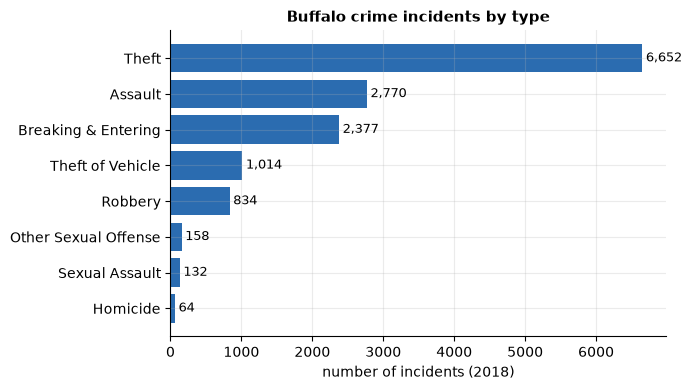

In [3]:
print("Incident types (crime_data_2018.csv):")
display(tbl["incident_type"].value_counts().rename("count").to_frame())

print("\nDays of week covered:", sorted(tbl["day_of_week"].unique()))
print(f"Missing coordinates : {tbl[['long', 'lat']].isna().any(axis=1).sum()}")

fig, ax = plt.subplots(figsize=(7, 4))
counts = tbl["incident_type"].value_counts()
ax.barh(counts.index[::-1], counts.values[::-1], color=C["blue"])
for i, v in enumerate(counts.values[::-1]):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=9)
ax.set_xlabel("number of incidents (2018)")
ax.set_title("Buffalo crime incidents by type")
plt.tight_layout(); plt.show()

### 5.1 A coordinate reference system problem

`buffalo_city.shp` (and the companion `Crime_location_2018.shp`) **declare** a coordinate reference system,
EPSG:3718 — NAD83(NSRS2007) / UTM zone 11N. That zone is defined for longitudes 114°W–120°W. Buffalo is at
**78.9°W**, thirty-eight degrees outside it. The transformation is still numerically computable, which is why
nothing raises an error, but every distance and area derived from those "native" coordinates is wrong. (Part 0
§0.5 works through the full diagnosis — the scale factor formula, the measured area distortion, and the
grid-rotation check.)

The `crime_data_2018.csv` table sidesteps the problem: it carries **longitude/latitude** (`long`, `lat`) as well,
computed independently of the mis-declared shapefile. We reproject those to the *correct* UTM zone for Buffalo,
**EPSG:26917 (UTM 17N, NAD83)**, and use that projected, metric CRS for every distance-based calculation in
Part 1. `buffalo_city.shp` is reprojected the safe way: through WGS84 longitude/latitude, not by trusting its own
declared CRS.

In [4]:
from pyproj import Transformer, CRS

declared = CRS.from_user_input(city.crs)
w, s, e, n = declared.area_of_use.bounds
print(f"buffalo_city.shp declares : {declared.name}")
print(f"  designed for longitudes : {w:.0f}\N{DEGREE SIGN} to {e:.0f}\N{DEGREE SIGN} "
      f"(Buffalo is at 78.9\N{DEGREE SIGN}W — outside this range)")

CRS_CORRECT = 26917  # NAD83 / UTM zone 17N — the correct zone for Buffalo

# City boundary: go through lon/lat, never trust the shapefile's own (wrong) CRS directly
city_fixed = city.to_crs(4326).to_crs(CRS_CORRECT)

# Crime locations: build directly from the CSV's independent long/lat columns
transformer = Transformer.from_crs(4326, CRS_CORRECT, always_xy=True)
x_m, y_m = transformer.transform(tbl["long"].to_numpy(), tbl["lat"].to_numpy())
coords_all = np.column_stack([x_m, y_m])

print(f"\nReprojected city area   : {city_fixed.area.sum() / 1e6:.1f} km²")
print(f"City's own 'sqmiles' attr: {city['sqmiles'].sum() * 2.589988:.1f} km²  (independent check — matches)")
print(f"Declared-CRS city area   : {city.area.sum() / 1e6:.1f} km²  "
      f"({100 * (city.area.sum() / city_fixed.area.sum() - 1):+.1f}% error if used as-is)")

buffalo_city.shp declares : NAD83(NSRS2007) / UTM zone 11N
  designed for longitudes : -120° to -114° (Buffalo is at 78.9°W — outside this range)



Reprojected city area   : 105.8 km²
City's own 'sqmiles' attr: 105.8 km²  (independent check — matches)
Declared-CRS city area   : 133.1 km²  (+25.7% error if used as-is)


**From here on, every notebook in Part 1 uses `coords_all` (built from `long`/`lat` via EPSG:26917) and
`city_fixed` (the city boundary reprojected the same way).** This is the single most important data-hygiene
step for Part 1 — every distance, area, intensity and K-function in the chapters that follow depends on it.

***
## 6. Building the Observation Window

`Window.from_gdf` takes the union of every polygon in a `GeoDataFrame` as $W$. Using the official city boundary
— rather than, say, the bounding box of the crime points — means the window reflects genuine city limits: lakes,
industrial land and the areas outside city limits are excluded from the denominator of every intensity estimate.

Window(polygon, area=1.0583e+08, bounds=(670377.394, 4743812.67, 680296.782, 4759265.808))

is a simple rectangle : False
bounding box (m)      : (670377, 4743813, 680297, 4759266)
short side             : 9.92 km  (sets the default distance range for later K/L/pair-correlation plots)


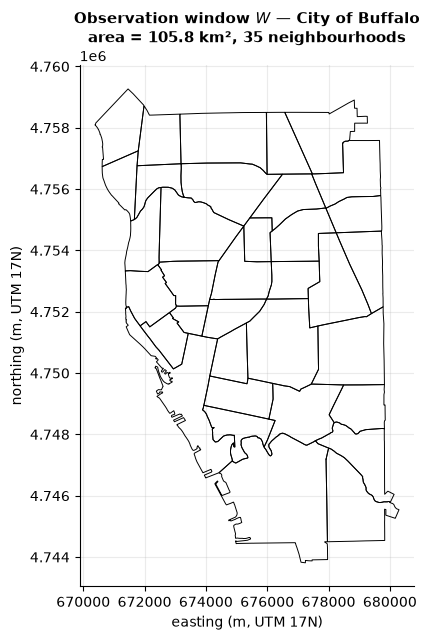

In [5]:
win_city = Window.from_gdf(city_fixed)

print(win_city)
print(f"\nis a simple rectangle : {win_city.is_rectangle}")
print(f"bounding box (m)      : {tuple(round(b) for b in win_city.bounds)}")
print(f"short side             : {win_city.short_side / 1000:.2f} km  "
      "(sets the default distance range for later K/L/pair-correlation plots)")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
city_fixed.boundary.plot(ax=ax, color="k", lw=0.7)
ax.set_aspect("equal")
ax.set_title(f"Observation window $W$ — City of Buffalo\narea = {win_city.area / 1e6:.1f} km², "
             f"{len(city_fixed)} neighbourhoods")
ax.set_xlabel("easting (m, UTM 17N)"); ax.set_ylabel("northing (m, UTM 17N)")
plt.tight_layout(); plt.show()

***
## 7. Constructing the Point Pattern

`PointPattern(coords, window=..., clip=True)` attaches the event coordinates to the window; `clip=True` drops
any event that falls outside $W$ rather than raising (a handful of geocoded points fall just outside city limits,
or across the river, and are not part of "crime in Buffalo").

PointPattern(n=13948, intensity=0.0001318, window=Window(polygon, area=1.0583e+08, bounds=(670377.394, 4743812.67, 680296.782, 4759265.808)))

events supplied   : 14,001
events inside W   : 13,948
dropped by clip   : 53  (0.38%, outside city limits)
average intensity : 131.80 events / km² (0.000132 events / m²)


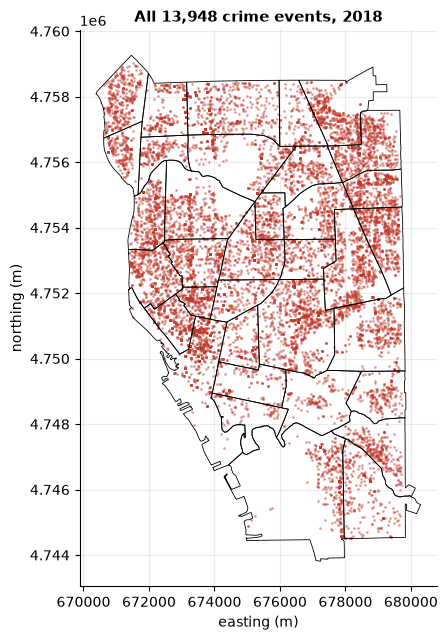

In [6]:
pp_all = PointPattern(coords_all, window=win_city, clip=True)

n_dropped = len(coords_all) - pp_all.n
print(pp_all)
print(f"\nevents supplied   : {len(coords_all):,}")
print(f"events inside W   : {pp_all.n:,}")
print(f"dropped by clip   : {n_dropped}  ({100 * n_dropped / len(coords_all):.2f}%, outside city limits)")
print(f"average intensity : {pp_all.intensity * 1e6:.2f} events / km² "
      f"({pp_all.intensity:.6f} events / m²)")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(pp_all.coords[:, 0], pp_all.coords[:, 1], s=1.2, alpha=0.35, color=C["red"])
city_fixed.boundary.plot(ax=ax, color="k", lw=0.6)
ax.set_aspect("equal")
ax.set_title(f"All {pp_all.n:,} crime events, 2018")
ax.set_xlabel("easting (m)"); ax.set_ylabel("northing (m)")
plt.tight_layout(); plt.show()

***
## 8. Marks: Crime Type as a Categorical Mark

Passing `marks=` attaches the incident type to each event. `by_mark()` extracts the sub-pattern of one type as
its own `PointPattern` — useful for the cross-type interaction questions of Chapter 1.4 (are thefts and assaults
found near each other, more than chance would predict?).

PointPattern(n=13948, intensity=0.0001318, window=Window(polygon, area=1.0583e+08, bounds=(670377.394, 4743812.67, 680296.782, 4759265.808)))
marks dtype : object,  distinct types: 8

Theft sub-pattern     : n = 6617  (intensity 62.52 / km²)
Homicide sub-pattern  : n = 64  (intensity 0.6047 / km²)


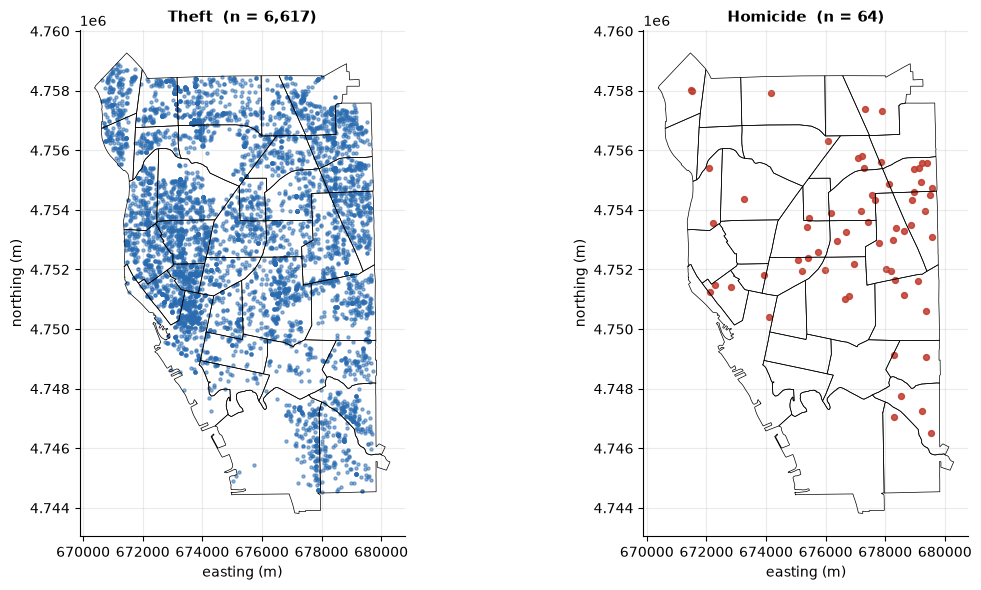

In [7]:
pp_marked = PointPattern(coords_all, window=win_city, marks=tbl["incident_type"].to_numpy(), clip=True)

print(pp_marked)
print(f"marks dtype : {pp_marked.marks.dtype},  distinct types: {len(np.unique(pp_marked.marks))}")

theft = pp_marked.by_mark("Theft")
homicide = pp_marked.by_mark("Homicide")
print(f"\nTheft sub-pattern     : n = {theft.n}  (intensity {theft.intensity * 1e6:.2f} / km²)")
print(f"Homicide sub-pattern  : n = {homicide.n}  (intensity {homicide.intensity * 1e6:.4f} / km²)")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, sub, name, col in zip(axes, [theft, homicide], ["Theft", "Homicide"], [C["blue"], C["red"]]):
    city_fixed.boundary.plot(ax=ax, color="k", lw=0.5)
    ax.scatter(sub.coords[:, 0], sub.coords[:, 1], s=5 if name == "Theft" else 18,
              alpha=0.5 if name == "Theft" else 0.85, color=col)
    ax.set_aspect("equal"); ax.set_title(f"{name}  (n = {sub.n:,})")
    ax.set_xlabel("easting (m)"); ax.set_ylabel("northing (m)")
plt.tight_layout(); plt.show()

Even at a glance, Theft (n ≈ 6,600) looks broadly spread with denser pockets, while Homicide (n = 64) is too
sparse to say much about visually — small marks require the formal tools of later chapters (and, for genuinely
rare events, the small-area methods of Part 5) rather than a map alone.

***
## 9. Duplicate Locations

Geocoded administrative data routinely produce **exact duplicate coordinates**: several incidents recorded at
the same street address, snapped to the same address point by the geocoder. Distance-based statistics (nearest-
neighbour distances, Chapter 1.3's K/L/pair-correlation functions) are sensitive to this — a duplicate creates
an inter-event distance of exactly zero, which is a data artefact, not evidence of point-process clustering.

In [8]:
n_dup = pp_all.n_duplicates
print(f"total events              : {pp_all.n:,}")
print(f"events sharing a location : {n_dup:,}  ({100 * n_dup / pp_all.n:.1f}%)")
print(f"distinct locations        : {pp_all.n - n_dup:,}")

pp_dedup = pp_all.deduplicate()
pp_jitter = pp_all.jitter(scale=5.0, seed=1)   # +/- 5 m, well under city-block scale

print(f"\nafter deduplicate() : n = {pp_dedup.n:,}  (keeps first occurrence only)")
print(f"after jitter(5 m)   : n = {pp_jitter.n:,}  (keeps every event, displaces ±5 m)")
print(f"jitter duplicates remaining: {pp_jitter.n_duplicates}")

total events              : 13,948
events sharing a location : 5,045  (36.2%)
distinct locations        : 8,903

after deduplicate() : n = 8,903  (keeps first occurrence only)
after jitter(5 m)   : n = 13,948  (keeps every event, displaces ±5 m)
jitter duplicates remaining: 0


Two legitimate responses, and they are not interchangeable:

- **`deduplicate()`** treats repeated coordinates as one *location* — appropriate when the question is about
  where events occur (e.g. the K-function analyses of Chapter 1.3, which assume distinct events).
- **`jitter()`** keeps every recorded event but displaces coincident ones by a small random amount — appropriate
  when the *count* matters (e.g. a quadrat or kernel-intensity estimate in Chapter 1.2, where each incident should
  still contribute to the density).

Chapter 1.3 uses `deduplicate()`; Chapter 1.2's intensity and quadrat methods use the full, non-deduplicated
pattern, since they count events rather than measure distances between them. Exercise 3 of Chapter 1.5 asks you
to quantify how much this choice changes the answer.

***
## 10. Alternative Windows: Bounding Box, Convex Hull, City Boundary

The window is a modelling choice, not a given. Three common options, compared on the same data:

In [9]:
win_bbox = Window.from_points(pp_all.coords)
win_hull = Window.convex_hull(pp_all.coords)
# win_city already built in Section 6

windows = {"Bounding box": win_bbox, "Convex hull": win_hull, "City boundary (used from here on)": win_city}
rows = []
for name, w in windows.items():
    rows.append({"window": name, "area (km²)": w.area / 1e6,
                 "implied intensity (events/km²)": pp_all.n / (w.area / 1e6)})
win_table = pd.DataFrame(rows).set_index("window")
win_table.round(2)

,area (km²),implied intensity (events/km²)
window,,
Bounding box,131.91,105.73
Convex hull,105.63,132.05
City boundary (used from here on),105.83,131.80


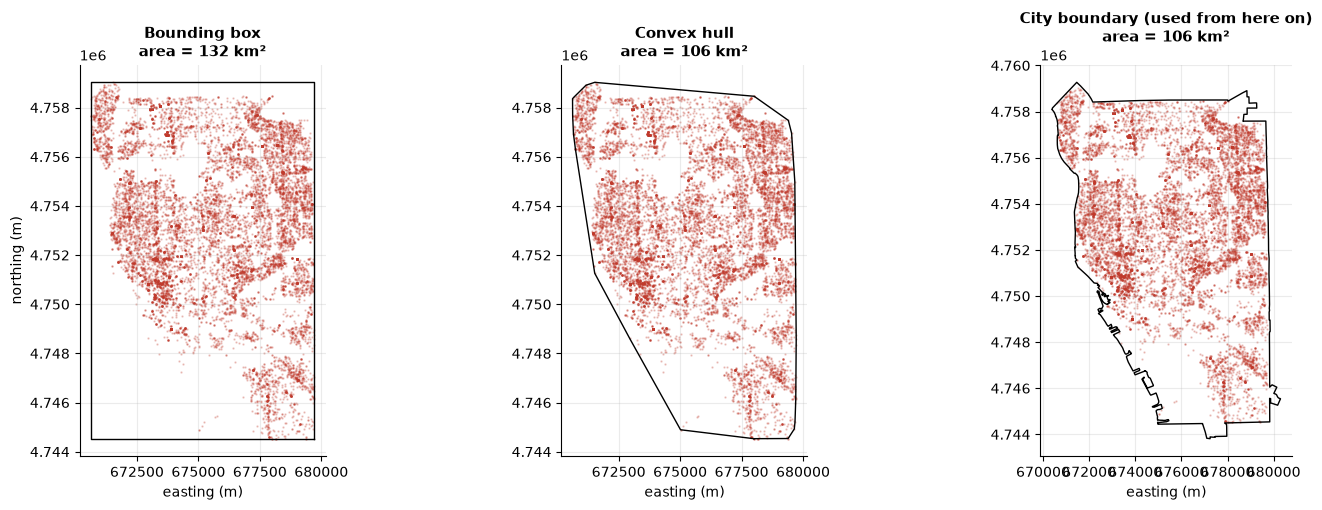

The bounding box is **1.25× larger** than the true city area, because Buffalo's boundary is irregular and the Niagara River frontage is not rectangular. Using it as the window would understate the true intensity by the same factor, and would let edge-correction routines in Chapter 1.3 search for neighbours across areas (open water, other municipalities) where events could never have been recorded.

The convex hull has almost the *same total area* as the city boundary (105.6 vs 105.8 km²) — but that similarity is misleading: its straight edges cut across the city's concave river frontage and **leak 3.9 km² outside city limits**, while simultaneously missing 4.1 km² of genuine city area that happens to have no crime points right at its edge. The two errors partly cancel in the *total*, but not in *where* the window is wrong — a reminder that matching areas is not the same as matching shapes.

**The city boundary is the only one of the three that matches how the data were actually generated**, which is why Section 6 used it and every later chapter in Part 1 does too.

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, (name, w) in zip(axes, windows.items()):
    geoms = getattr(w.polygon, "geoms", [w.polygon])
    for g in geoms:
        xg, yg = g.exterior.xy
        ax.plot(xg, yg, color="k", lw=1)
    ax.scatter(pp_all.coords[:, 0], pp_all.coords[:, 1], s=0.5, alpha=0.25, color=C["red"])
    ax.set_aspect("equal")
    ax.set_title(f"{name}\narea = {w.area / 1e6:.0f} km²")
    ax.set_xlabel("easting (m)")
axes[0].set_ylabel("northing (m)")
plt.tight_layout(); plt.show()

ratio = win_bbox.area / win_city.area
hull_leak = win_hull.polygon.difference(win_city.polygon).area
hull_miss = win_city.polygon.difference(win_hull.polygon).area
display(Markdown(
    f"The bounding box is **{ratio:.2f}× larger** than the true city area, because Buffalo's boundary is "
    "irregular and the Niagara River frontage is not rectangular. Using it as the window would understate the "
    "true intensity by the same factor, and would let edge-correction routines in Chapter 1.3 search for "
    "neighbours across areas (open water, other municipalities) where events could never have been recorded.\n\n"
    f"The convex hull has almost the *same total area* as the city boundary ({win_hull.area / 1e6:.1f} vs "
    f"{win_city.area / 1e6:.1f} km²) — but that similarity is misleading: its straight edges cut across "
    f"the city's concave river frontage and **leak {hull_leak / 1e6:.1f} km² outside city limits**, while "
    f"simultaneously missing {hull_miss / 1e6:.1f} km² of genuine city area that happens to have no crime "
    "points right at its edge. The two errors partly cancel in the *total*, but not in *where* the window is "
    "wrong — a reminder that matching areas is not the same as matching shapes.\n\n"
    "**The city boundary is the only one of the three that matches how the data were actually generated**, "
    "which is why Section 6 used it and every later chapter in Part 1 does too."
))

***
## 11. A First Look at Randomness

To build intuition before the formal tests of Chapter 1.4, `simulate_csr` draws a complete-spatial-randomness
pattern with exactly the observed count $n$, uniformly distributed over the *same* window $W$ (the binomial
process of Section 3.2). Placing it next to the real data is a first, informal check.

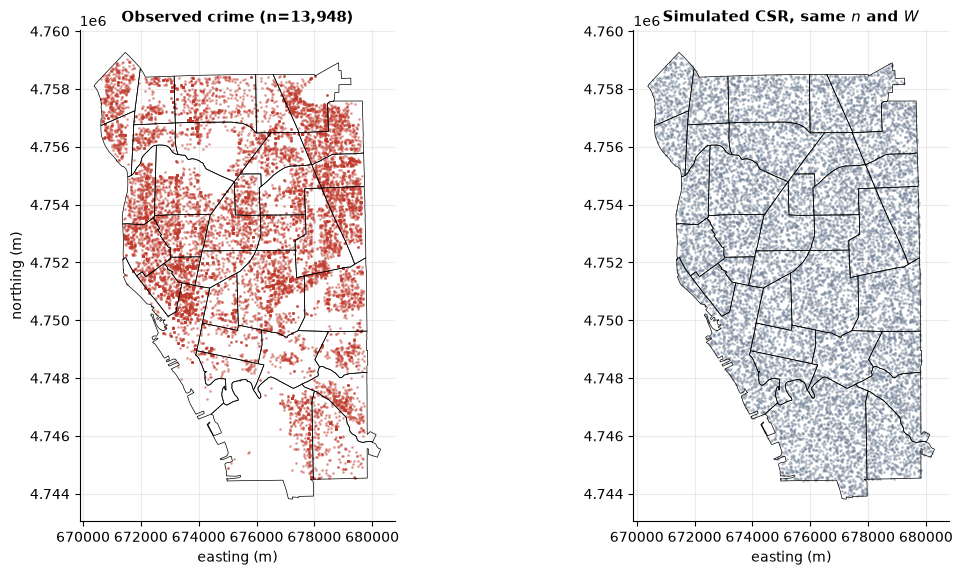

In [11]:
pp_csr = simulate_csr(n=pp_all.n, window=win_city, seed=7)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, sub, title, col in zip(axes, [pp_all, pp_csr],
                               [f"Observed crime (n={pp_all.n:,})", f"Simulated CSR, same $n$ and $W$"],
                               [C["red"], C["grey"]]):
    city_fixed.boundary.plot(ax=ax, color="k", lw=0.5)
    ax.scatter(sub.coords[:, 0], sub.coords[:, 1], s=1.2, alpha=0.35, color=col)
    ax.set_aspect("equal"); ax.set_title(title)
    ax.set_xlabel("easting (m)")
axes[0].set_ylabel("northing (m)")
plt.tight_layout(); plt.show()

The two maps look nothing alike: the simulated CSR pattern is uniformly smudged across the city, while the real
data show visible denser pockets and emptier stretches. That impression is exactly what **intensity estimation**
(Chapter 1.2) and the **formal CSR tests** of Chapter 1.4 make precise and quantify — a picture is a hypothesis,
not a result.

***
## 12. Summary and Conclusions

This chapter built the foundations that the rest of Part 1 relies on.

### What we did

1. Distinguished point pattern data (random *locations*) from the lattice and geostatistical data of other Parts.
2. Defined events, the observation window $W$, marks, and the first-order/second-order distinction.
3. Stated complete spatial randomness as the homogeneous Poisson process, and previewed clustered and regular
   alternatives.
4. Loaded the 2018 Buffalo crime data and **diagnosed a coordinate reference system error** in the source
   shapefiles (declared UTM zone 11N; Buffalo is in zone 17N) — fixed by reprojecting through longitude/latitude
   to EPSG:26917.
5. Built the observation window from the official city boundary, and the marked `PointPattern` from the
   corrected coordinates, with `clip=True` handling the handful of out-of-window points.
6. Quantified duplicate geocoded locations (about a third of all events) and demonstrated `deduplicate()` versus
   `jitter()` as two different, non-interchangeable responses.
7. Compared the city boundary against a bounding box and a convex hull, and showed the bounding box overstates
   the window area by a large factor.
8. Simulated a CSR pattern with the same count and window as a first, informal benchmark.

### Practical takeaways

- **Always audit the CRS before computing anything spatial.** A shapefile can declare a valid CRS that is still
  wrong for the data it contains, and nothing will raise an error.
- **The window is part of the model, not an afterthought.** Use the region that actually could have produced
  the data, not a computational convenience like a bounding box.
- **Duplicates need a decision, not an assumption.** Whether to deduplicate or jitter depends on whether the
  question is about *locations* or *counts*.
- `clip=True` on `PointPattern` is the right default for real-world data with a few stray points near a
  boundary; the alternative (raising an error) is better when out-of-window points signal a genuine data bug.

### Next steps

**Chapter 1.2 (First-order Analysis: Spatial Intensity)** takes the `pp_all` pattern built here and asks *how*
the intensity $\lambda(\mathbf{s})$ varies across the city: quadrat counts, kernel density estimation, and
relative-risk surfaces that compare one crime type against the rest.

***
## 13. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Baddeley, A., Rubak, E. & Turner, R. (2015). *Spatial Point Patterns: Methodology and Applications with R*. CRC Press. | The standard modern reference; companion to the `spatstat` R package |
| Diggle, P. J. (2013). *Statistical Analysis of Spatial and Spatio-Temporal Point Patterns* (3rd ed.). CRC Press. | Concise, classic treatment; CSR and its alternatives |
| Illian, J., Penttinen, A., Stoyan, H. & Stoyan, D. (2008). *Statistical Analysis and Modelling of Spatial Point Patterns*. Wiley. | Comprehensive; strong on point process theory |
| Cressie, N. (1993). *Statistics for Spatial Data*. Wiley. | Chapter 8 covers point processes alongside the other two data types |

### Key papers

| Paper | Contribution |
|---|---|
| Ripley, B. D. (1977). Modelling spatial patterns. *Journal of the Royal Statistical Society B*, 39, 172–212. | Foundational paper introducing second-order methods (Chapter 1.3) |
| Neyman, J. & Scott, E. L. (1958). Statistical approach to problems of cosmology. *JRSS B*, 20, 1–43. | Origin of the parent–offspring cluster process used in Chapter 1.4 |
| Matérn, B. (1960). *Spatial Variation*. Meddelanden från Statens Skogsforskningsinstitut. | Origin of the hard-core inhibition process used in Chapter 1.4 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.pointpattern.Window` | Observation window: `from_gdf`, `from_points`, `convex_hull`, `from_bounds` |
| `spatialstats.pointpattern.PointPattern` | Events + window + optional marks; `from_gdf`, `n_duplicates`, `deduplicate`, `jitter`, `by_mark`, `subset` |
| `spatialstats.pointpattern.simulate_csr` | Complete spatial randomness, as a Poisson (`intensity=`) or binomial (`n=`) process |
| `spatialstats.core.crs`, `pyproj` | CRS validation and reprojection (Part 0 §0.5 has the full CRS audit workflow) |
| Chapter 1.2 | Intensity estimation: `quadrat_test`, `kde`, `relative_risk` |
| Chapter 1.3 | Second-order functions: `ripley_k`, `ripley_l`, `pair_correlation`, `g_function`, `f_function`, `j_function` |
| Chapter 1.4 | Hypothesis tests: `envelope`, `simulate_thomas`, `simulate_matern_inhibition`, `k_inhom`, `cross_k` |